# Groundhog 🔁
### Do stocks have 'favourite months'? Absurd — and it's real

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Genuinely same-month seasonal?: Confirmed](https://img.shields.io/badge/Genuinely_same--month_seasonal%3F-Confirmed-8b949e?style=flat-square)

Here's a claim that sounds like astrology: a stock tends to repeat its **calendar-month** performance — a name that's done well in past Marches keeps doing well in Marches. It should be nonsense. Instead it's the most robust effect on this bench: significant, specific to the same month, and it hasn't faded in 26 years. One honesty flag carried throughout: we measure it on **today's S&P 500 survivors**, which inflates the size of the win — the *existence* rests on a control that shares that bias (and on the original study's bias-free data).

> 📓 **Plain-language layer.** The control, the t-stat and the cost sweep are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (groundhog/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from groundhog import data, strategy as st
# Opt-in, stated: current S&P 500 members + a >=20y-history filter = a twice-survivor panel.
# Magnitudes below are upper bounds; the same-month-vs-other-month control shares the bias.
ret = data.fetch_panel(allow_survivorship_bias=True)   # cache-first; built by examples/verify.py --fetch
same = st.seasonal_hedge(ret, same_month=True)
ctrl = st.seasonal_hedge(ret, same_month=False)


C:\Users\loutr\Dropbox\Perso\GitHub\Open-Alpha-Lab\studies\48-groundhog\groundhog\strategy.py:45: RuntimeWarning: Mean of empty slice
  pred = np.nanmean(R[rows, :], axis=0)


C:\Users\loutr\Dropbox\Perso\GitHub\Open-Alpha-Lab\studies\48-groundhog\groundhog\strategy.py:45: RuntimeWarning: Mean of empty slice
  pred = np.nanmean(R[rows, :], axis=0)


## The answer first 🎯

| You'd assume | The data says |
|---|---|
| "Calendar months are noise" | Long-short on same-month history: **+7.3%/yr, t = 4.1** — on a survivor panel, so read the size as an upper bound. |
| "It's just momentum" | Ranking on *other* months earns **−3.3%/yr** — it's the same month, specifically (and this control shares the panel's bias). |
| "Surely it's decayed" | Sharpe **0.81** in both halves of the sample. |
| "Then it's free money" | Counted one-way, break-even is **~19 bp/trade** — thin. |

## 1 · The claim

Heston & Sadka (2008): a stock's average return in a given calendar month predicts its return in that same month in future years. Rank by same-month history, long the winners, short the losers — a pure cross-sectional seasonal.

## 2 · So what?

If returns carry a stable calendar-month fingerprint, that's a free, decorrelated source of cross-sectional alpha — and a genuine puzzle for efficient markets. But 'a stock likes March' is exactly the kind of pattern that screams data-mining, so the test has to be airtight.

## 3 · How would we even know?

The airtight test is a **control**: rank stocks by their *other*-month history instead of the same month. If only the same month predicts, it's a real seasonal; if other months predict too, it's just generic persistence. The control does double duty here: our panel is **today's index members with 20+ years of history** — survivors — which flatters any long-short you run on it. But the control runs on the *same* survivors, so the bias cancels out of the *comparison*, even though it doesn't cancel out of the headline magnitude.

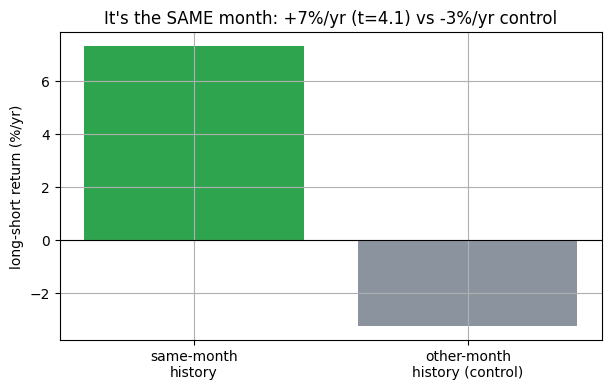

In [2]:
s, c = st.stats(same), st.stats(ctrl)
fig,ax=plt.subplots(figsize=(7,4))
ax.bar(['same-month\nhistory','other-month\nhistory (control)'],[s['mean_ann']*100,c['mean_ann']*100],color=['#2ea44f','#8b949e'])
ax.set_ylabel('long-short return (%/yr)'); ax.axhline(0,color='k',lw=.8)
ax.set_title(f"It's the SAME month: +{s['mean_ann']*100:.0f}%/yr (t={s['tstat']:.1f}) vs {c['mean_ann']*100:.0f}%/yr control"); plt.show()

## 4 · The teardown

The same-month book compounds; the control bleeds. And the effect is as strong in the second half of the sample as the first.

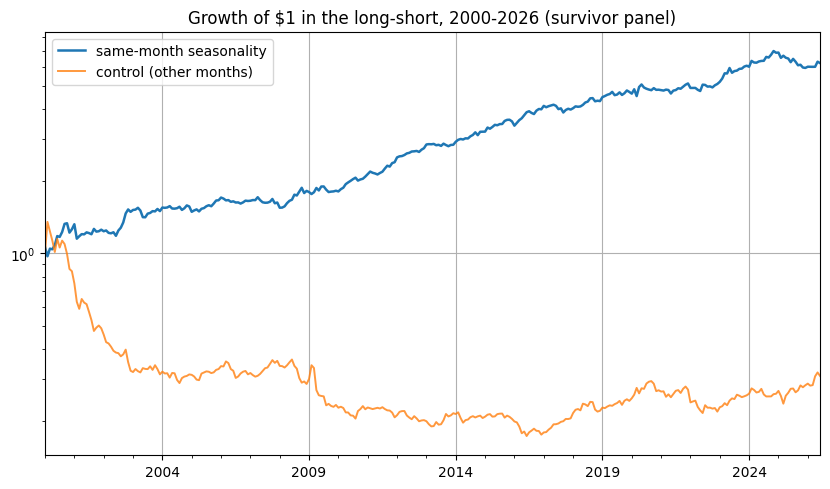

2000-2012: Sharpe +0.81
2013-on: Sharpe +0.81


In [3]:
eq=(1+same).cumprod(); eqc=(1+ctrl).cumprod()
ax=eq.plot(label='same-month seasonality',lw=1.8); eqc.plot(ax=ax,label='control (other months)',lw=1.4,alpha=.8)
ax.set_yscale('log'); ax.set_title('Growth of $1 in the long-short, 2000-2026 (survivor panel)'); ax.legend(); plt.show()
for lab,sl in [('2000-2012',same.loc[:'2012']),('2013-on',same.loc['2013':])]:
    print(f'{lab}: Sharpe {st.stats(sl)["sharpe"]:+.2f}')

**Read it plainly.** The weird thing is true. A stock really does carry a same-month fingerprint, and it's persisted for a generation — the opposite of the decayed mirages elsewhere on this bench. Just don't bank the +7.3%/yr literally: a panel made of today's winners overstates how much any long-short earned.

## 5 · The verdict

**Signal: Real** — t 4.1, undecayed, same-month-specific; the *magnitude* is inflated by the survivor panel, the *existence* is what the control (which shares the bias) and the original CRSP study support. **Tradability: Fragile** — counted one-way it breaks even at ~19 bp and needs a big short book. **Same-month seasonal?: Confirmed** — the control fails.

## 6 · Could you actually trade it?

Only just — and that's the honest 'fragile'. The book replaces ~80% of both sides each month, which is ~3.2× your capital in one-way trades: break-even **~19 bp per trade**, net Sharpe **0.38 at 10 bp**, and shorting ~80 names costs borrow on top (25–50 bp/yr trims it to ~0.33–0.36) — all on a survivor universe that flatters the gross. The effect is real; the *net you keep* is thin and uncertain.

## 7 · Going further 🚪

The quants notebook has the cost sweep and break-even. Next: [Study 49 Black-Gold](../../49-black-gold/) — does the price of oil predict the stock market?